# Probando modelos para prediccion

- Mario Castro
- Oscar Senday
- Esthefania Ortega

## Acomodando dataset

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('../data/processed/rickettsia_for_predictions.csv')

In [17]:
df['estatus_caso'].value_counts()

estatus_caso
3    1635
2     459
1     322
Name: count, dtype: int64

In [18]:
# Tenemos multiples estados, pero solo queremos predecir los confirmados (2) y probables (1)

df["target"] = (
    (df["estatus_caso"] == 1) | (df["estatus_caso"] == 2)
).astype(bool)

In [19]:
df['target'].value_counts()

target
False    1635
True      781
Name: count, dtype: int64

In [20]:
X = df.drop(columns=["estatus_caso", "target"])
y = df["target"]

----

## Preproceso para los modelos

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

Split para todos los modelos:

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [26]:
numeric_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = X.select_dtypes(
    include=["object", "category", 'str']
).columns

In [27]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [ ]:
# =========================
# Models + parameter grids
# =========================

model_grids = {

    "Logistic Regression": {
        "model": LogisticRegression(max_iter=5000),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"]
        }
    },

    "SVM": {
        "model": SVC(probability=True),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 300],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.1],
            "model__max_depth": [3, 5]
        }
    }
}

Despues de seleccionar los hiperparametros, el codigo siguiente es para el reporte de resultados y entrenamientos:

In [31]:
results = []

best_models = {}

for name, config in model_grids.items():

    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", config["model"])
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    best_models[name] = best_model

    print("\nBest Parameters:")
    print(grid_search.best_params_)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Training Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters:
{'model__C': 0.01, 'model__solver': 'liblinear'}

Classification Report:
              precision    recall  f1-score   support

       False       0.77      0.92      0.84       328
        True       0.73      0.44      0.55       156

    accuracy                           0.77       484
   macro avg       0.75      0.68      0.69       484
weighted avg       0.76      0.77      0.75       484


Training SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters:
{'model__C': 0.1, 'model__gamma': 'auto', 'model__kernel': 'rbf'}

Classification Report:
              precision    recall  f1-score   support

       False       0.68      1.00      0.81       328
        True       1.00      0.03      0.05       156

    accuracy                           0.69       484
   macro avg       0.84      0.51      0.43       484
weighted avg       0.79      0.

In [32]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Best Params,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,"{'model__max_depth': 10, 'model__min_samples_l...",0.764463,0.733333,0.423077,0.536585,0.778006
1,SVM,"{'model__C': 0.1, 'model__gamma': 'auto', 'mod...",0.685950,1.000000,0.025641,0.050000,0.774508
0,Logistic Regression,"{'model__C': 0.01, 'model__solver': 'liblinear'}",0.766529,0.731183,0.435897,0.546185,0.769211
3,Gradient Boosting,"{'model__learning_rate': 0.01, 'model__max_dep...",0.758264,0.740741,0.384615,0.506329,0.764716


Generando curvas de aprendizaje:

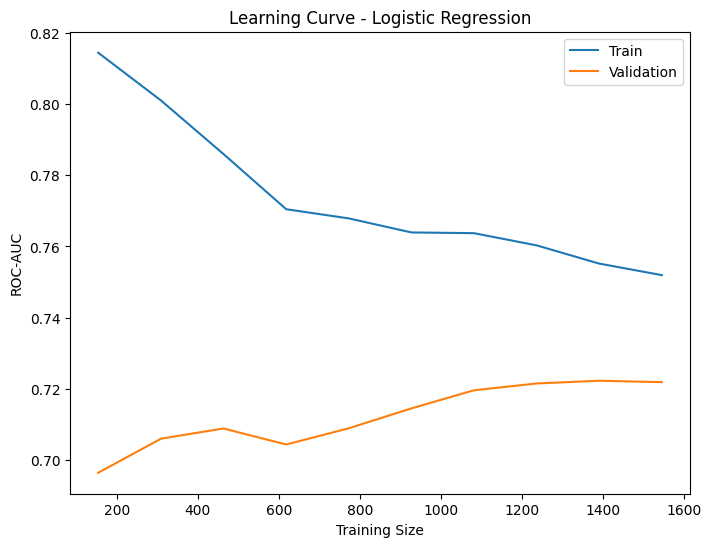

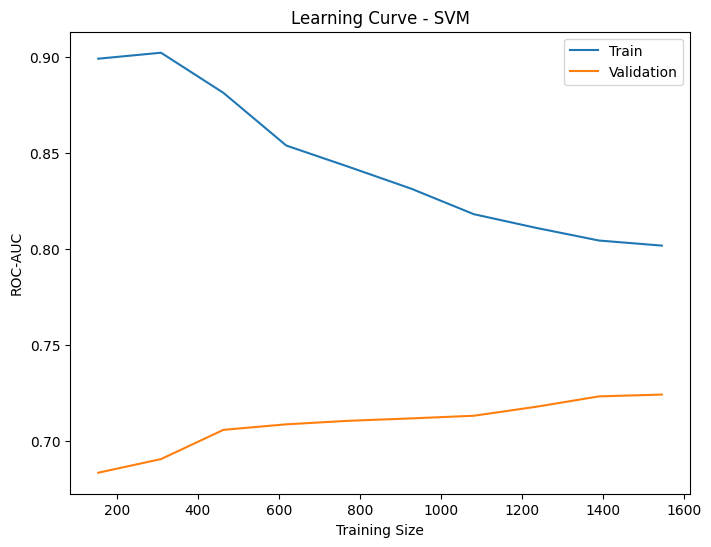

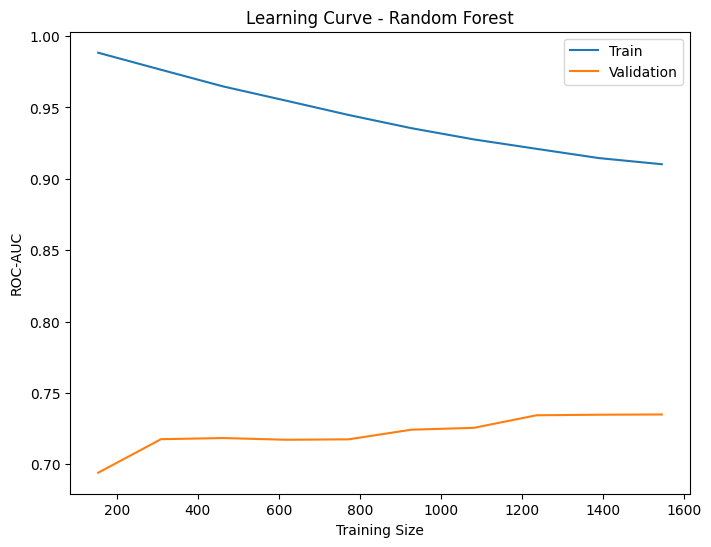

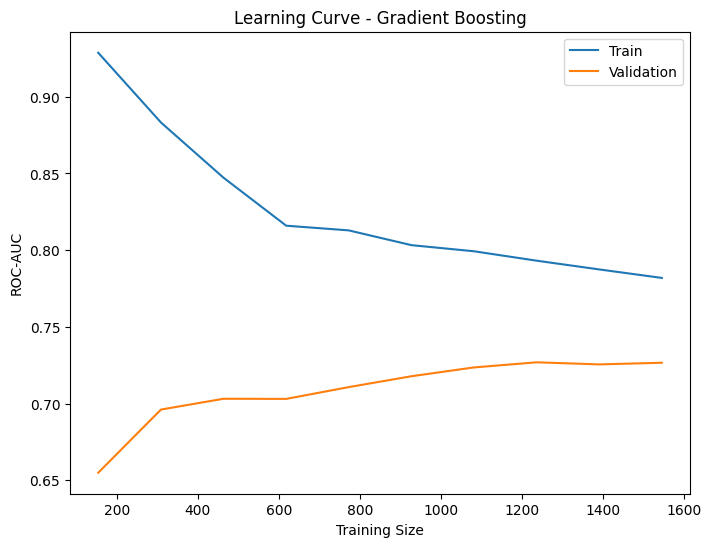

In [34]:
for name, model in best_models.items():

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=5,
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8, 6))

    plt.plot(train_sizes, train_mean, label="Train")
    plt.plot(train_sizes, val_mean, label="Validation")

    plt.title(f"Learning Curve - {name}")

    plt.xlabel("Training Size")
    plt.ylabel("ROC-AUC")

    plt.legend()

    plt.show()